---
# 1. Section A - Dataset & EDA
## A1. Dataset Loading & Audit

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## 1. Load Communities.data

In [2]:

df = pd.read_csv('communities.csv')
display(df.head())
print("\nDATAFRAME SHAPE:", df.shape)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03



DATAFRAME SHAPE: (1994, 128)


## 2. Dataset Audit

In [3]:

df.info()
display(df.describe(include='all').T.head())

print("DATA TYPES")
for dtype, count in df.dtypes.value_counts().items():
    print(f"{str(dtype):<10}: {count} columns")
non_numeric = df.select_dtypes(exclude="number").columns.tolist()
print(f"\nNon-numeric columns  : {non_numeric}")


<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(125), int64(2), str(1)
memory usage: 1.9 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
state,1994.0,NaN,NaN,NaN,28.683551,16.397553,1.0,12.0,34.0,42.0,56.0
county,820.0,NaN,NaN,NaN,58.826829,126.42056,1.0,9.0,23.0,59.5,840.0
community,817.0,NaN,NaN,NaN,46188.336597,25299.726569,70.0,25065.0,48090.0,66660.0,94597.0
communityname,1994,1828,Jacksonvillecity,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fold,1994.0,NaN,NaN,NaN,5.493982,2.873694,1.0,3.0,5.0,8.0,10.0


DATA TYPES
float64   : 125 columns
int64     : 2 columns
str       : 1 columns

Non-numeric columns  : ['communityname']


## 3. Missing Value Analysis

In [4]:

print("MISSING VALUES : ")
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(1)
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_%", ascending=False)

print(f"Total missing cells            : {df.isna().sum().sum()}")
print(f"Columns with missing values    : {len(missing)} of {df.shape[1]}")
print(f"Columns with no missing values : {df.shape[1] - len(missing)}\n")
display(missing)

MISSING VALUES : 
Total missing cells            : 39202
Columns with missing values    : 25 of 128
Columns with no missing values : 103



,missing_count,missing_%
LemasSwFTPerPop,1675,84.0
LemasTotalReq,1675,84.0
LemasSwornFT,1675,84.0
LemasSwFTFieldPerPop,1675,84.0
LemasSwFTFieldOps,1675,84.0
LemasTotReqPerPop,1675,84.0
RacialMatchCommPol,1675,84.0
PolicPerPop,1675,84.0
PolicReqPerOffic,1675,84.0
OfficAssgnDrugUnits,1675,84.0


## 4. Target Distribution

Target variable: ViolentCrimesPerPop

Distribution summary:
count    1994.000
mean        0.238
std         0.233
min         0.000
25%         0.070
50%         0.150
75%         0.330
max         1.000
Name: ViolentCrimesPerPop, dtype: float64

Skewness: 1.523


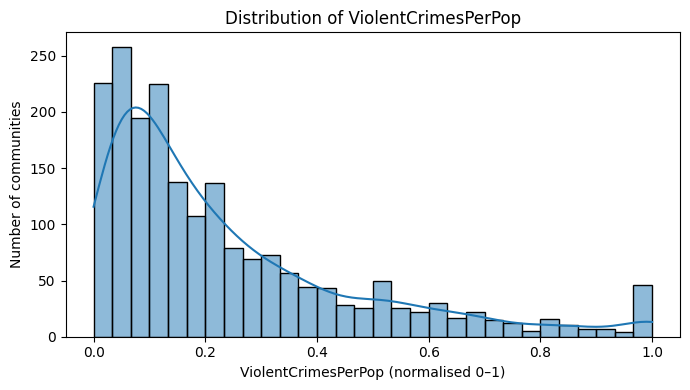

In [5]:
target = df.columns[-1]

print("Target variable:", target)
print("\nDistribution summary:")
print(df[target].describe().round(3))
print("\nSkewness:", round(df[target].skew(), 3))

plt.figure(figsize=(7, 4))
sns.histplot(df[target], kde=True, bins=30)
plt.title(f"Distribution of {target}")
plt.xlabel(f"{target} (normalised 0–1)")
plt.ylabel("Number of communities")
plt.tight_layout()
plt.show()

## target distribution - Observation 

Plotting distributions for 100 features (ID columns and >50%-missing columns excluded)


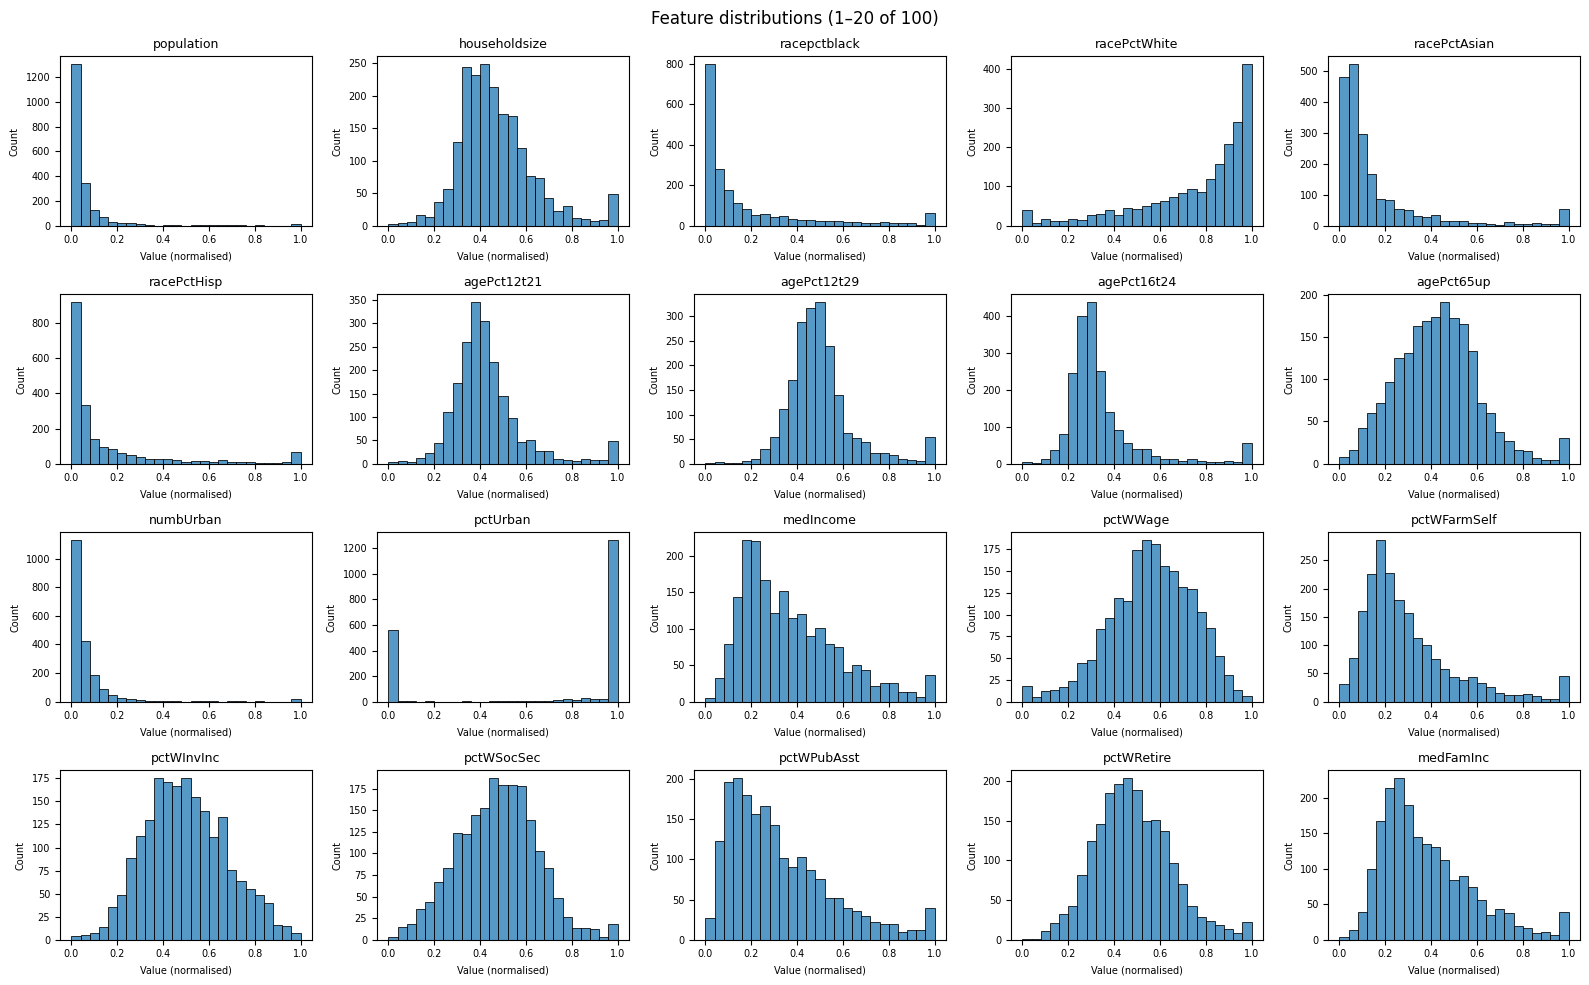

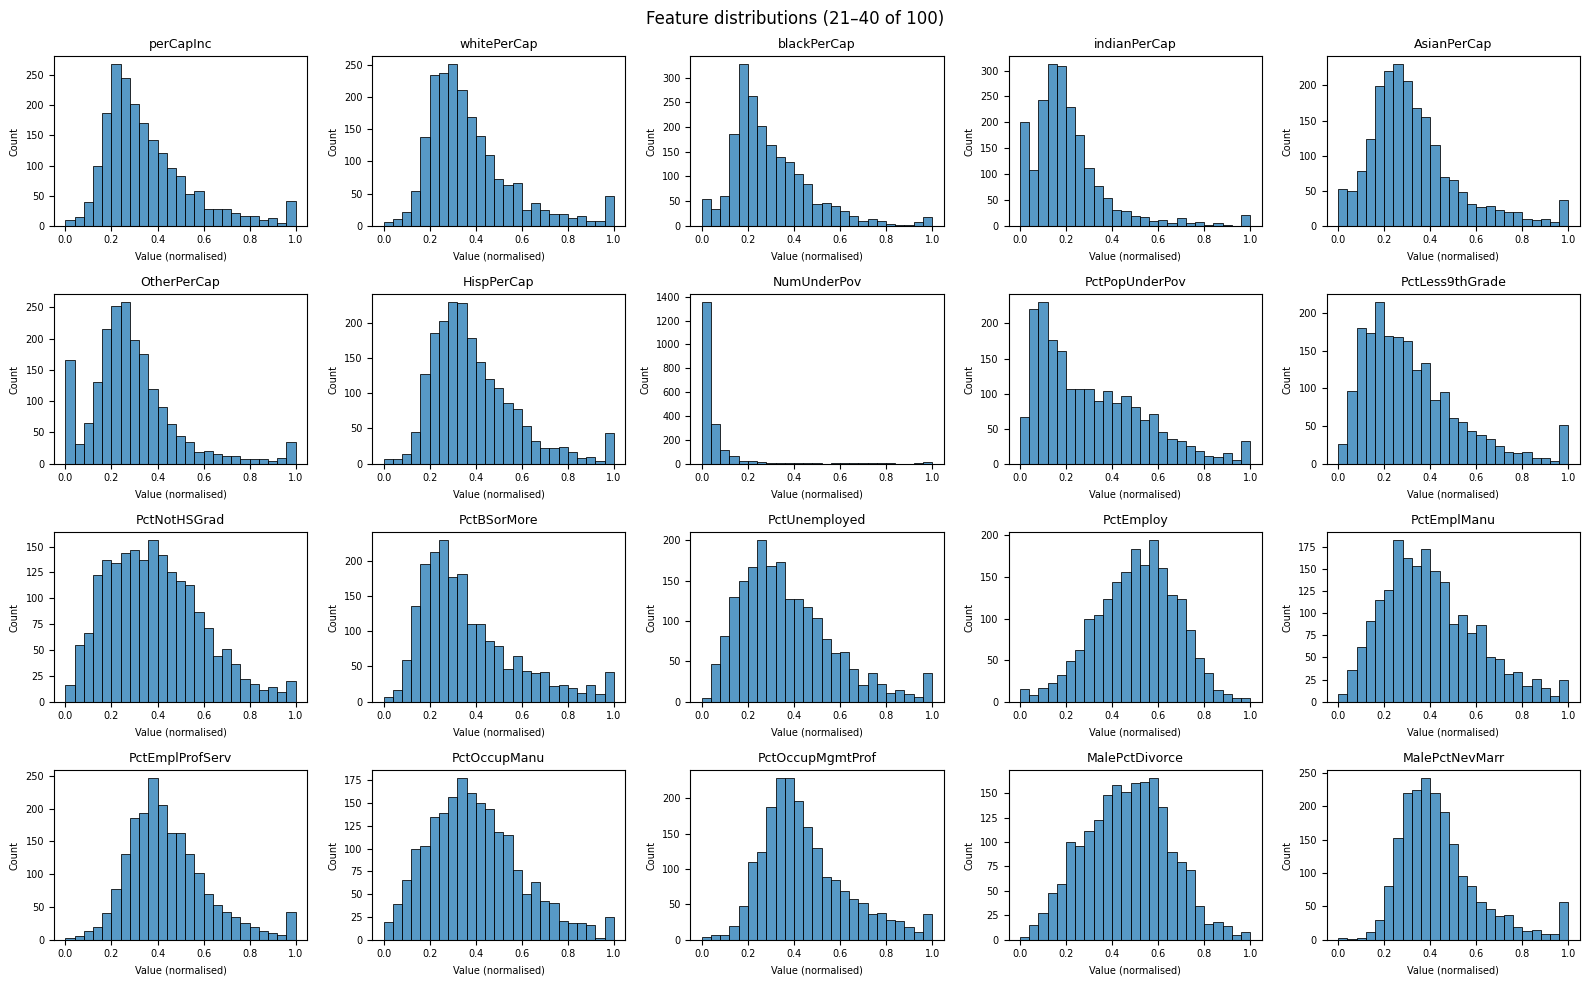

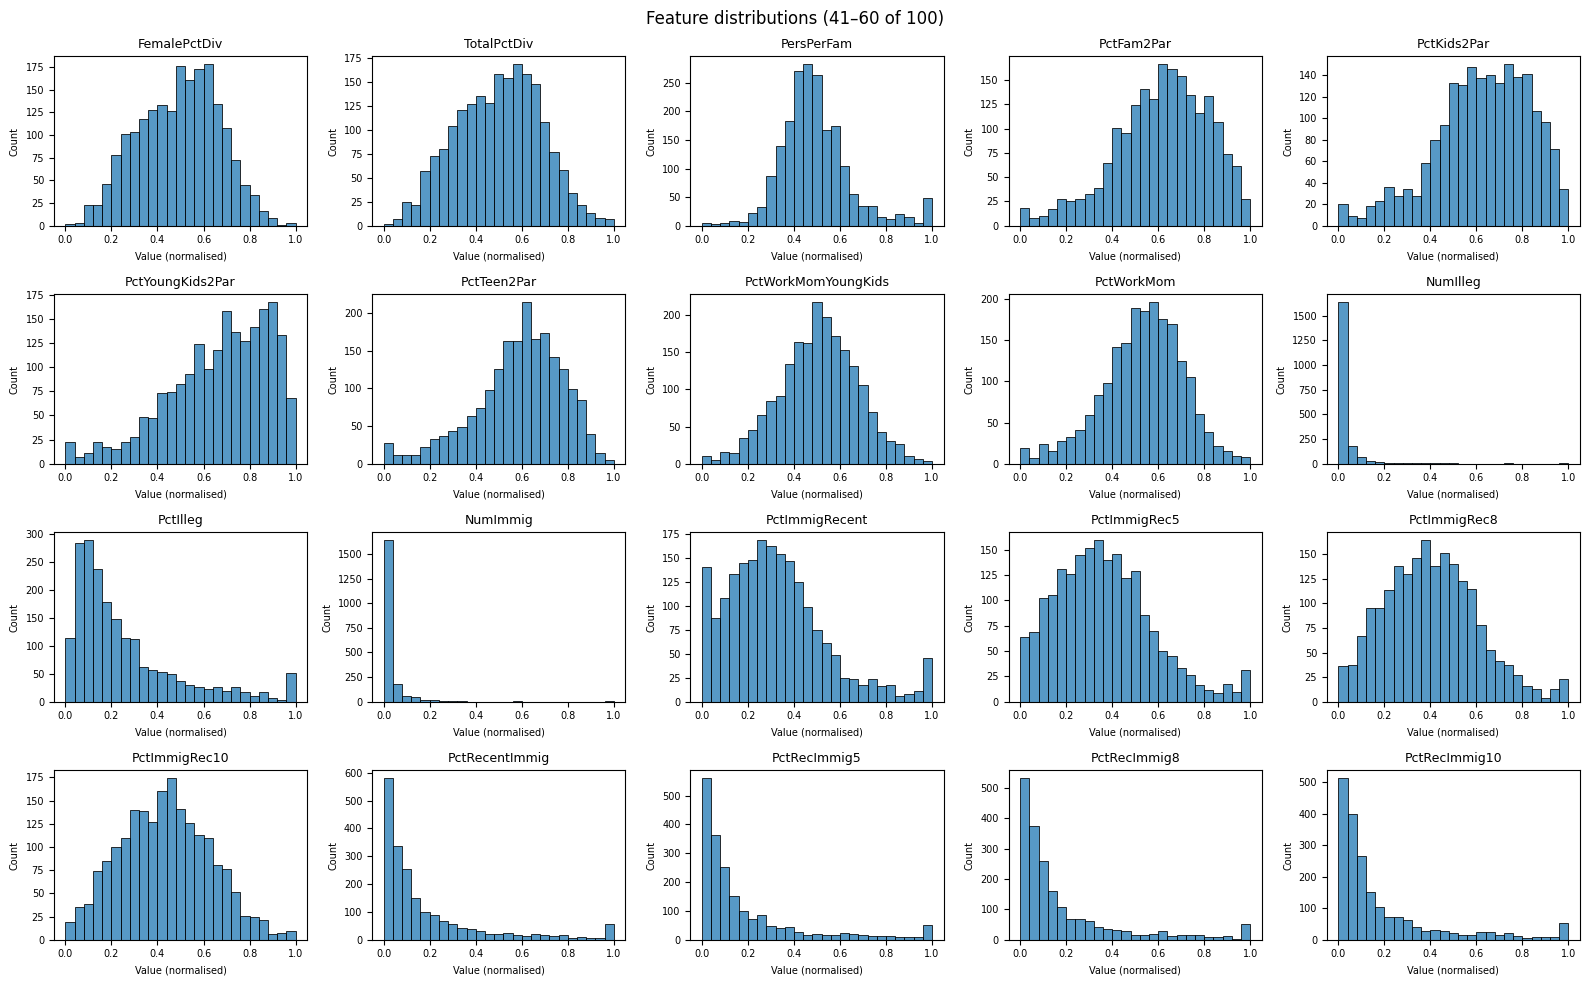

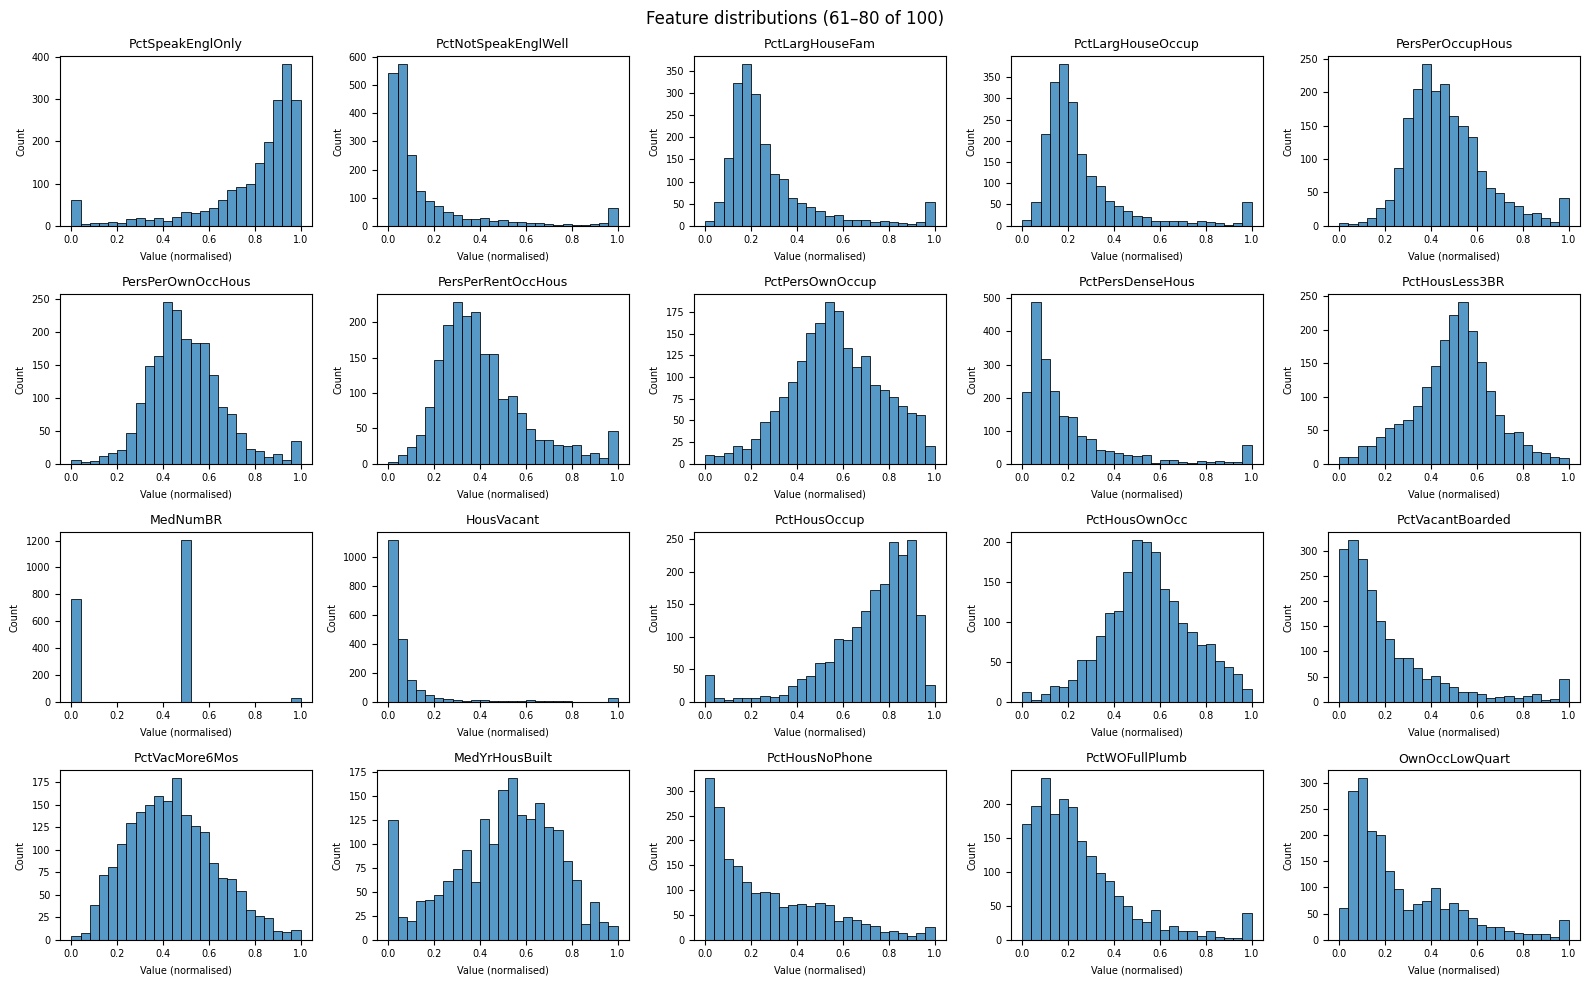

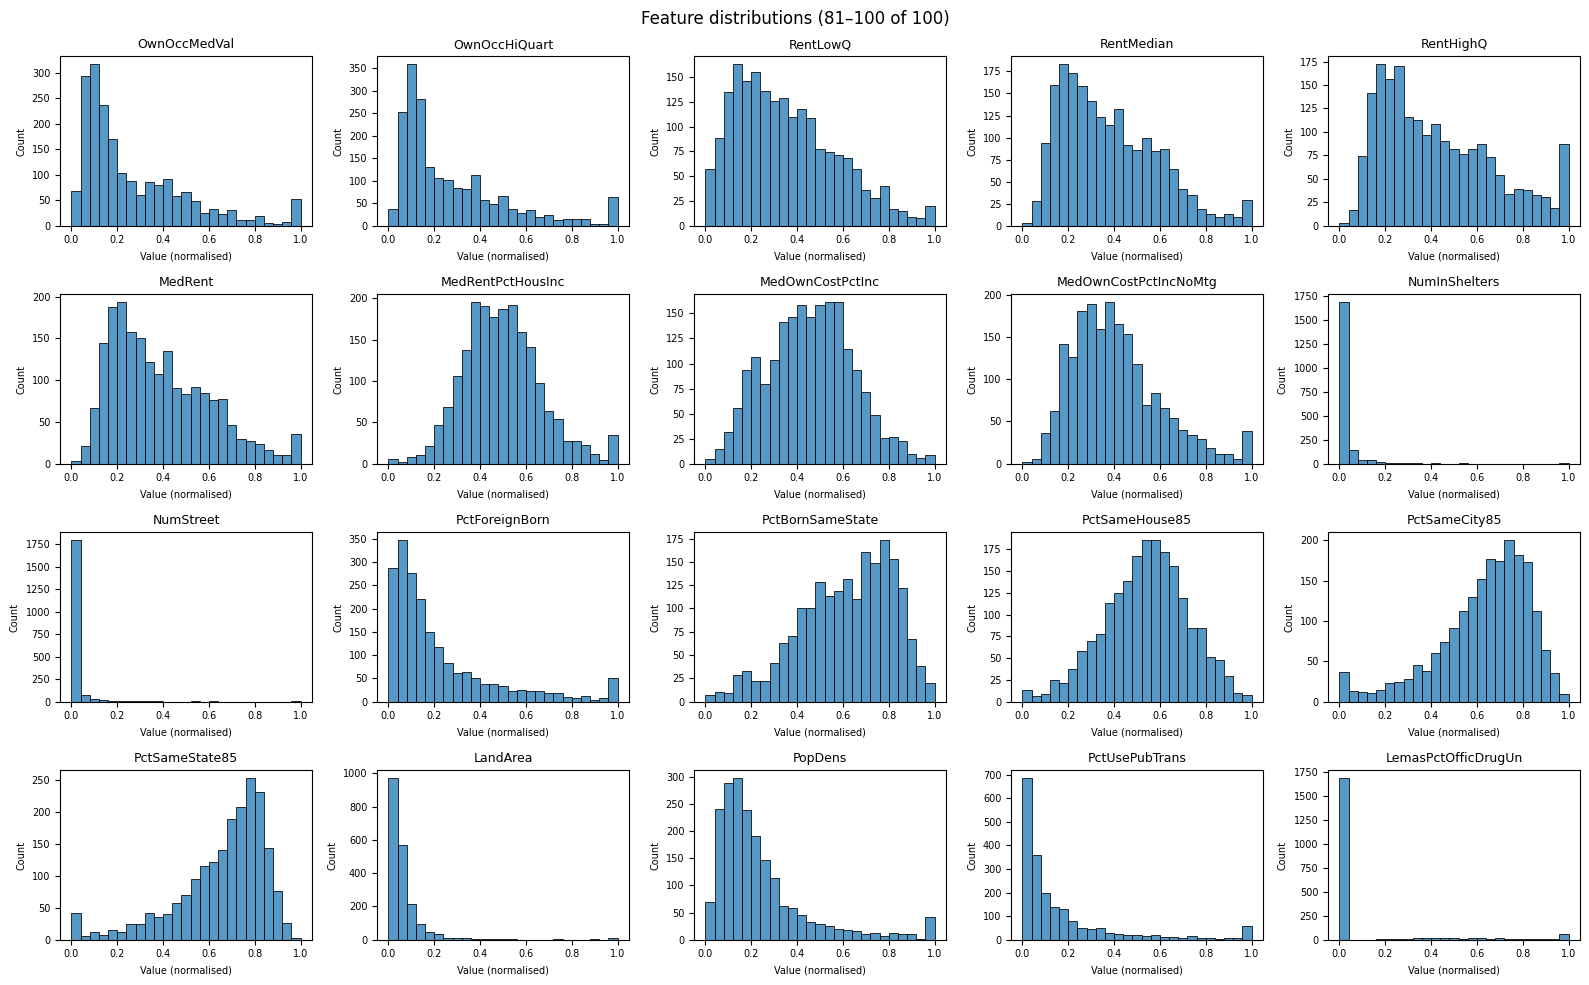

In [6]:
id_cols = ["state", "county", "community", "communityname", "fold"]
features = [c for c in df.columns
            if c not in id_cols + [target] and df[c].isna().mean() <= 0.5]

print(f"Plotting distributions for {len(features)} features (ID columns and >50%-missing columns excluded)")

for start in range(0, len(features), 20):
    batch = features[start:start + 20]
    fig, axes = plt.subplots(4, 5, figsize=(16, 10))
    for ax, col in zip(axes.flat, batch):
        sns.histplot(df[col], bins=25, ax=ax)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("Value (normalised)", fontsize=7)
        ax.set_ylabel("Count", fontsize=7)
        ax.tick_params(labelsize=7)
    for ax in axes.flat[len(batch):]:
        ax.axis("off")
    fig.suptitle(f"Feature distributions ({start + 1}–{start + len(batch)} of {len(features)})")
    plt.tight_layout()
    plt.show()

## 10. Correlation Heatmap


The heatmap below shows the pairwise correlation between all features and the target variable. It was built with the following choices:

- **Numeric columns only:** correlation is only defined for numeric data, so the text column (`communityname`) is left out.
- **ID and bookkeeping columns excluded:** `state`, `county`, `community` and `fold` are identifier codes, not real measurements. Their correlation with crime would have no meaning.
- **Heavily missing columns excluded:** the 22 police-survey (LEMAS) columns are about 84% missing, so their correlations would rest on only 319 of 1,994 communities and could mislead. These columns are dropped in the cleaning step.

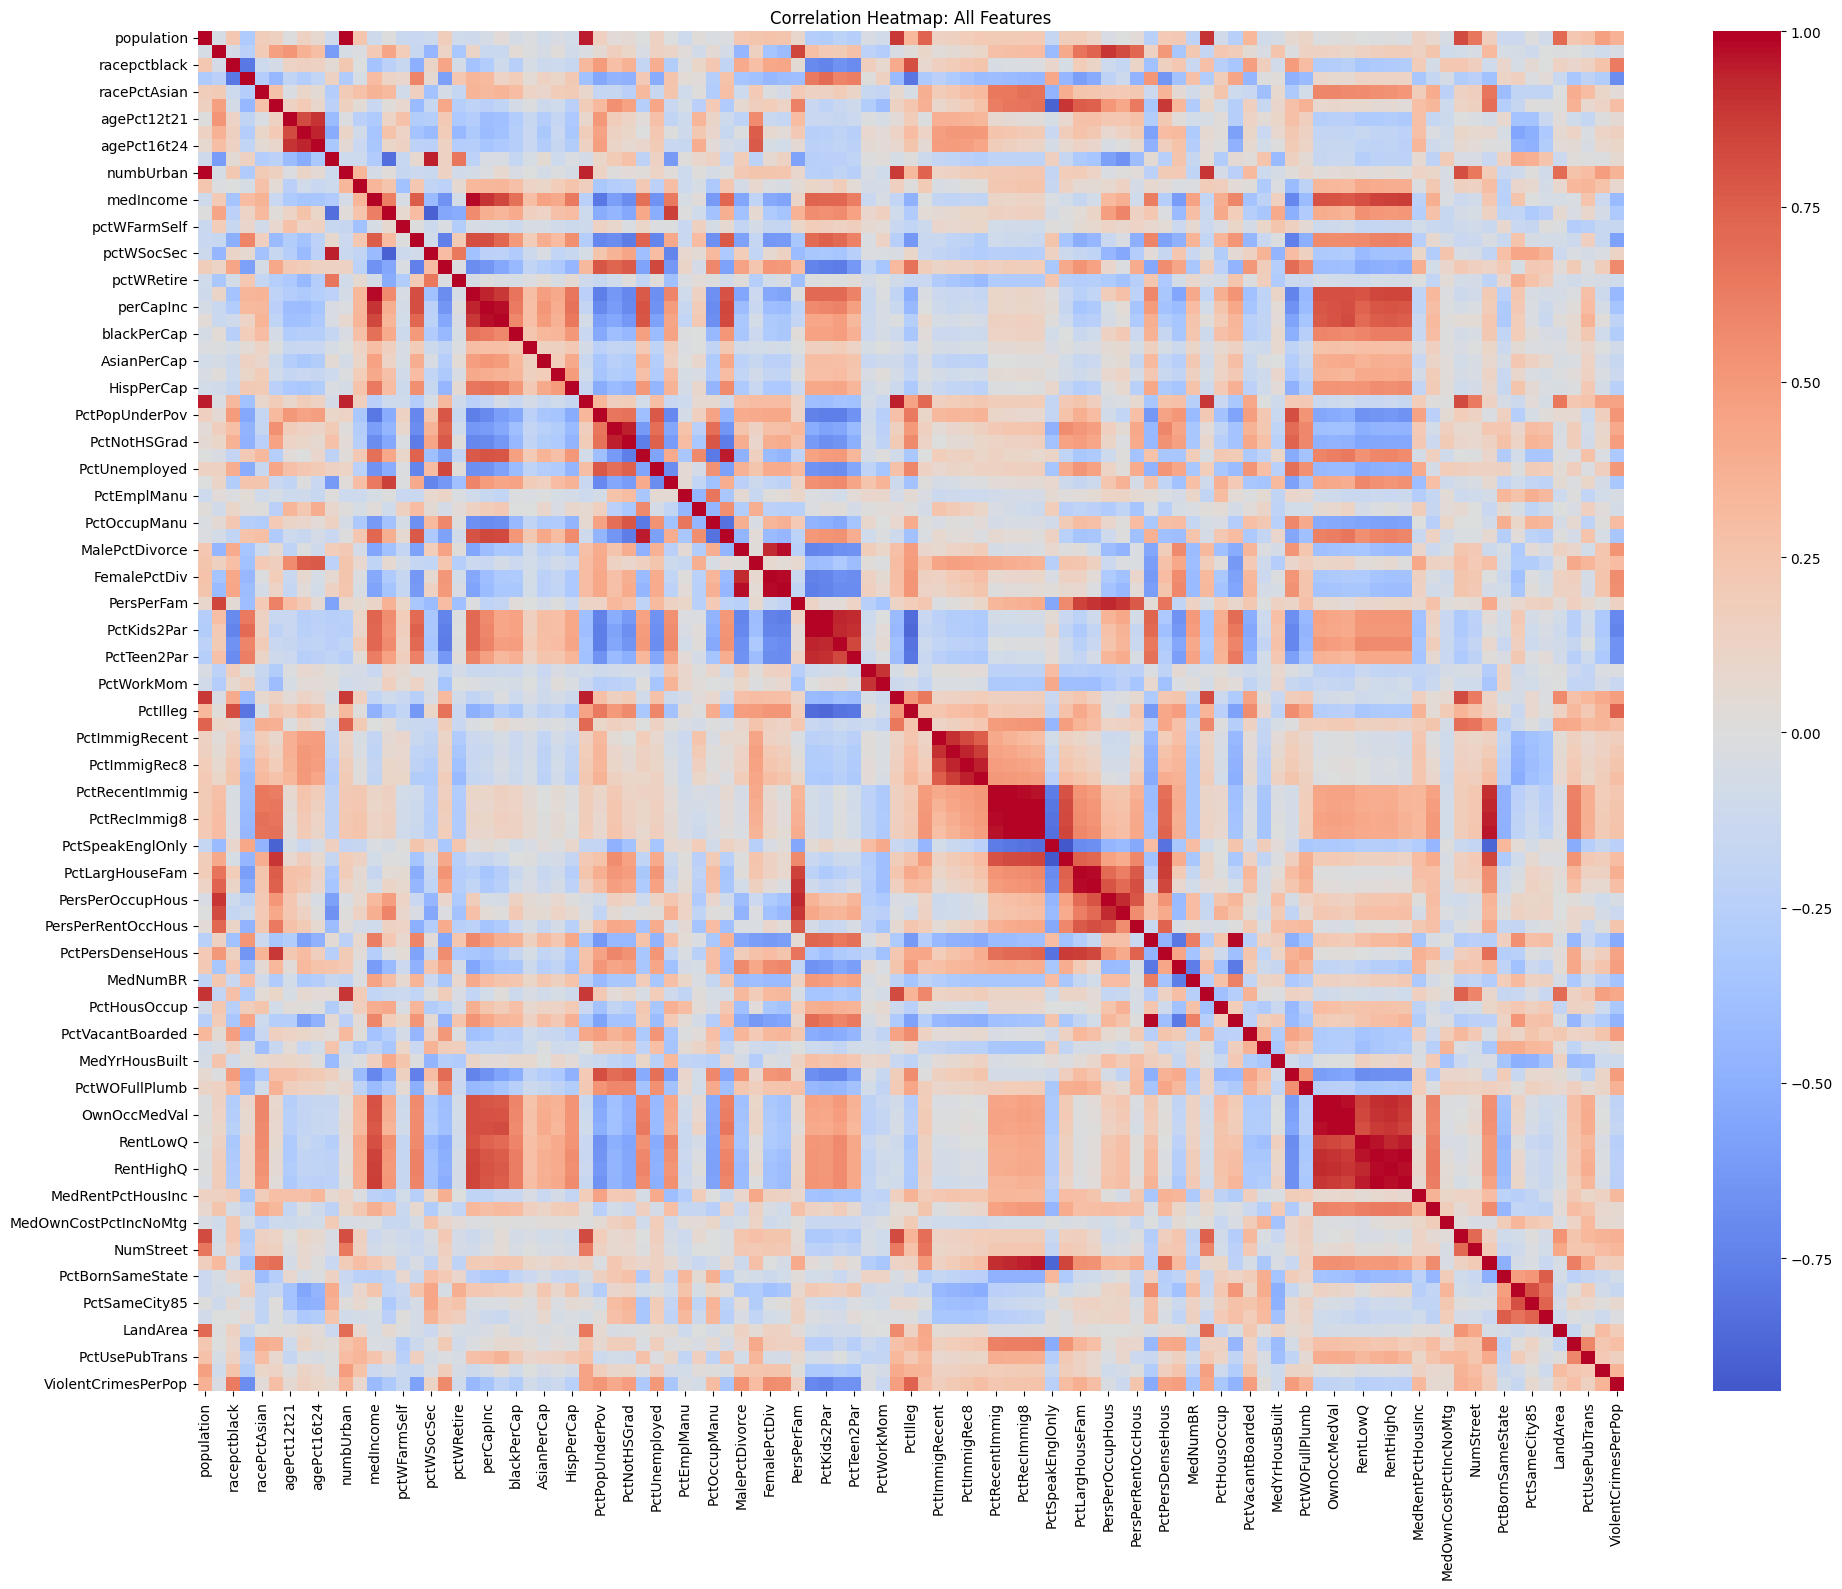

In [7]:
plt.figure(figsize=(20, 16))
sns.heatmap(df[features + [target]].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: All Features")
plt.tight_layout()
plt.show()

## Correlation Analysis, Feature vs target scatter plots

Correlation of 100 features with ViolentCrimesPerPop

Top 10 POSITIVE correlations
PctIlleg          0.738
racepctblack      0.631
pctWPubAsst       0.575
FemalePctDiv      0.556
TotalPctDiv       0.553
MalePctDivorce    0.525
PctPopUnderPov    0.522
PctUnemployed     0.504
PctHousNoPhone    0.488
PctNotHSGrad      0.483
dtype: float64

Top 10 NEGATIVE correlations
PctKids2Par        -0.738
PctFam2Par         -0.707
racePctWhite       -0.685
PctYoungKids2Par   -0.666
PctTeen2Par        -0.662
pctWInvInc         -0.576
PctPersOwnOccup    -0.525
PctHousOwnOcc      -0.471
medFamInc          -0.439
medIncome          -0.424
dtype: float64

Top 5 features plotted: ['PctKids2Par', 'PctIlleg', 'PctFam2Par', 'racePctWhite', 'PctYoungKids2Par']


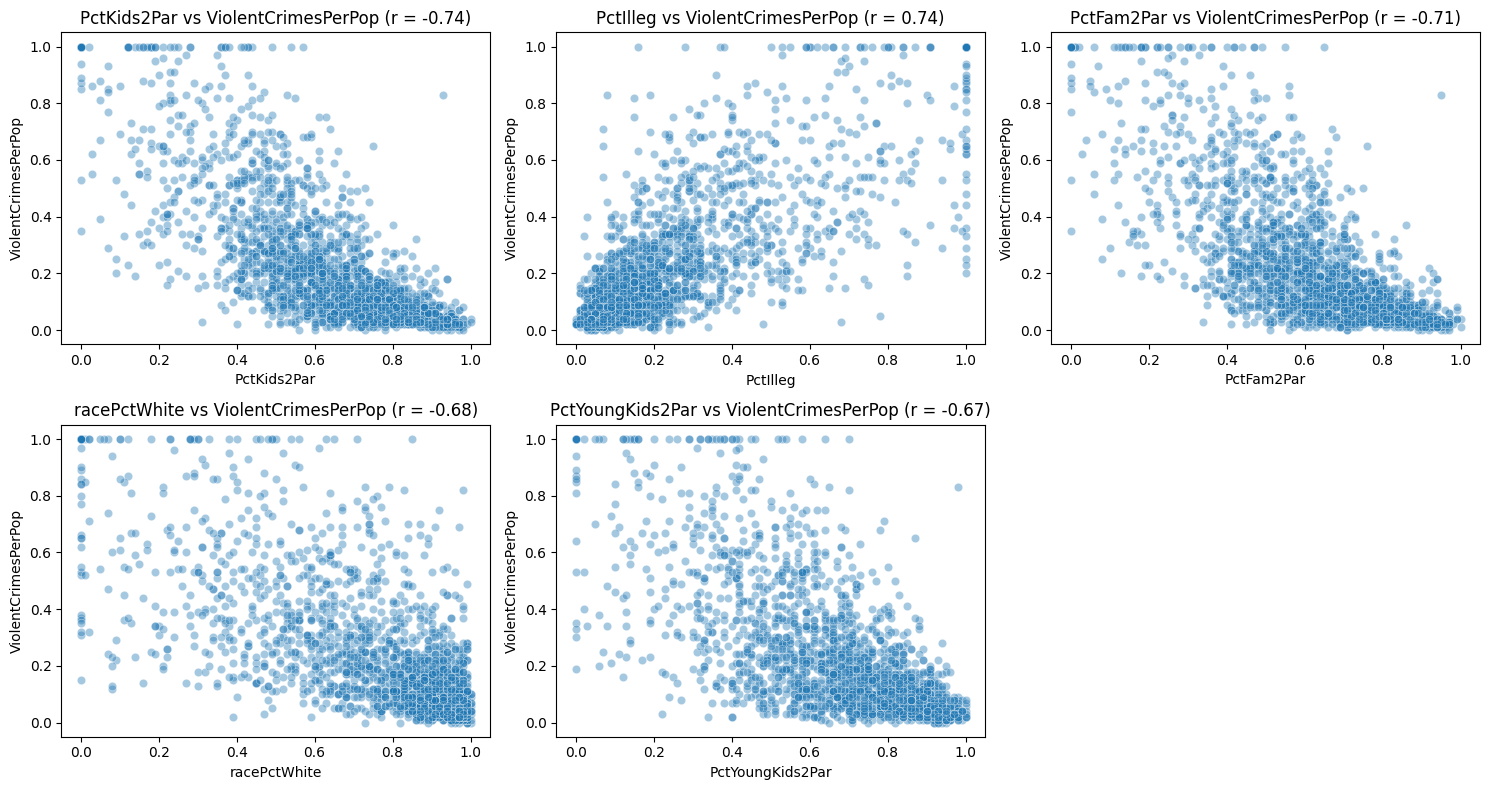

In [8]:
# Correlation of every feature with the target
corr_with_target = df[features].corrwith(df[target]).sort_values(ascending=False)

print(f"Correlation of {len(corr_with_target)} features with {target}")
print("\nTop 10 POSITIVE correlations")
print(corr_with_target.head(10).round(3))
print("\nTop 10 NEGATIVE correlations")
print(corr_with_target.tail(10).sort_values().round(3))

# Top 5 features by strength (positive or negative)
top5 = corr_with_target.abs().sort_values(ascending=False).head(5).index
print("\nTop 5 features plotted:", list(top5))

# Feature vs target scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, top5):
    sns.scatterplot(data=df, x=feat, y=target, alpha=0.4, ax=ax)
    ax.set_title(f"{feat} vs {target} (r = {corr_with_target[feat]:.2f})")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

---
# Section B: Preprocessing & Feature Engineering
The preprocessing pipeline runs in this order:

1. Drop sparse and identifier columns, check duplicates and outliers.
2. Create an engineered feature.
3. Split the data into train and test sets.
4. Cap outliers, impute the remaining missing value, and scale.

**Avoiding data leakage:** every step that learns a value from the data (percentile limits, the median, the mean and standard deviation) is fitted on the **training set only** and then applied to the test set.

### 1. Missing-Value Strategy: Drop Sparse and Identifier Columns

In [9]:
missing_pct = df.isna().mean() * 100
high_missing = missing_pct[missing_pct > 50].index.tolist()
id_cols = ["state", "county", "community", "communityname", "fold"]
cols_to_drop = sorted(set(high_missing + id_cols))

df_clean = df.drop(columns=cols_to_drop).copy()

print("Columns with >50% missing :", len(high_missing))
print("ID / bookkeeping columns  :", id_cols)
print("Total columns dropped     :", len(cols_to_drop))
print(f"Shape before: {df.shape}  ->  after: {df_clean.shape}")
print("Missing values left       :", int(df_clean.isna().sum().sum()))

Columns with >50% missing : 24
ID / bookkeeping columns  : ['state', 'county', 'community', 'communityname', 'fold']
Total columns dropped     : 27
Shape before: (1994, 128)  ->  after: (1994, 101)
Missing values left       : 1


### 2. Duplicate Check

In [10]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


### 3. Outlier Detection (IQR Rule)

In [11]:
X_check = df_clean.drop(columns=target)
Q1, Q3 = X_check.quantile(0.25), X_check.quantile(0.75)
IQR = Q3 - Q1
is_outlier = (X_check < Q1 - 1.5 * IQR) | (X_check > Q3 + 1.5 * IQR)

print("Features with at least one outlier:", (is_outlier.sum() > 0).sum(), "of", X_check.shape[1])
print("Communities with at least one outlier:", f"{is_outlier.any(axis=1).mean() * 100:.1f}%")
print("\nTop 10 features by % of outliers:")
display((is_outlier.mean() * 100).sort_values(ascending=False).head(10).round(1))

Features with at least one outlier: 92 of 100
Communities with at least one outlier: 77.1%

Top 10 features by % of outliers:


NumStreet              19.9
NumInShelters          19.9
LemasPctOfficDrugUn    15.5
NumIlleg               12.4
NumImmig               12.3
PctNotSpeakEnglWell    11.6
racePctHisp            11.5
population             10.9
racepctblack           10.9
racePctAsian           10.8
dtype: float64

### 4. Feature Engineering
**New feature:** `FamilyStructureAvg` = the mean of `PctKids2Par`, `PctFam2Par`, `PctYoungKids2Par` and `PctTeen2Par`. All four describe the share of two-parent households from different angles.

The feature is created **before the split**. A row-wise average uses no statistics from the dataset, so it causes no leakage.

In [12]:
family_cols = ["PctKids2Par", "PctFam2Par", "PctYoungKids2Par", "PctTeen2Par"]
df_clean["FamilyStructureAvg"] = df_clean[family_cols].mean(axis=1)

print("Correlation with", target)
for col in family_cols + ["FamilyStructureAvg"]:
    print(f"  {col:<20} {df_clean[col].corr(df_clean[target]):.3f}")

Correlation with ViolentCrimesPerPop
  PctKids2Par          -0.738
  PctFam2Par           -0.707
  PctYoungKids2Par     -0.666
  PctTeen2Par          -0.662
  FamilyStructureAvg   -0.715


### 5. Encoding of Categorical Features
**No categorical encoding is needed.** After treating the missing values, the only text column (`communityname`) has been dropped and all **101 remaining features are numeric**. `state` is a numeric identifier code (1–56), not a measurement, so it was dropped with the other identifier columns and not encoded.

### 6. Stratified Train/Test Split

In [13]:
X = df_clean.drop(columns=target)
y = df_clean[target]

y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
# print(f"Target mean   -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
# print(f"Target median -> train: {y_train.median():.3f} | test: {y_test.median():.3f}")

Train: (1595, 101) | Test: (399, 101)


### 7. Outlier Treatment: Capping at the 1st and 99th Percentile
Values below the 1st or above the 99th percentile of each feature are set to those limits (winsorising). The percentiles come from the **training set only** and are applied to both sets.

Percentile capping is used instead of the 1.5 × IQR rule because sparse features such as `NumStreet` have an IQR of zero, and capping them at 1.5 × IQR would turn them into constant columns.

In [14]:
lower = X_train.quantile(0.01)
upper = X_train.quantile(0.99)

X_train = X_train.clip(lower, upper, axis=1)
X_test = X_test.clip(lower, upper, axis=1)
print("Extreme values capped at the 1st and 99th percentile (limits taken from the training set only)")

Extreme values capped at the 1st and 99th percentile (limits taken from the training set only)


### 8. Imputation & Scaling

In [15]:

from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("Missing values left -> train:", int(X_train.isna().sum().sum()), "| test:", int(X_test.isna().sum().sum()))
print("Scaled train mean (should be ~0):", round(X_train_scaled.mean().mean(), 3))
print("Scaled train std  (should be ~1):", round(X_train_scaled.std().mean(), 3))
print("Final shapes:", X_train_scaled.shape, X_test_scaled.shape)
# print("Feature names kept:", list(X_train_scaled.columns[:4]), "...")

Missing values left -> train: 0 | test: 0
Scaled train mean (should be ~0): -0.0
Scaled train std  (should be ~1): 1.0
Final shapes: (1595, 101) (399, 101)


---
# 3. Section C - Regression Track
## C1. Model Implementations

Global Engine Results Array

In [16]:
results = []
models_dict = {}

def eval_model(name, model, X_tr, X_te, y_tr, y_te):
    '''Executes fitting, generation of metrics, and dynamic styled DataFrame printing.'''
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2 = r2_score(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae = mean_absolute_error(y_te, pred)

    results.append({'Model': name, 'R²': r2, 'RMSE': rmse, 'MAE': mae})
    models_dict[name] = model

    # Styled Evaluation Render
    metrics_df = pd.DataFrame({'Metric': ['R² (Variance Explained)', 'RMSE (Root Mean Sq Error)', 'MAE (Mean Abs Error)'], 'Score': [r2, rmse, mae]})

    cm = sns.light_palette("seagreen", as_cmap=True)
    display(metrics_df.style.set_caption(f"🚀 Diagnostics: {name}").background_gradient(cmap=cm, subset=['Score']).format({"Score": "{:.4f}"}).hide(axis="index"))
    return model

### 0. DummyRegressor (Baseline)

A DummyRegressor predicts the mean of the training target for all samples. This sets the absolute floor for model performance.

In [17]:
dummy = eval_model("DummyRegressor (Baseline)", DummyRegressor(strategy="mean"), X_train_scaled, X_test_scaled, y_train, y_test)

Metric,Score
R² (Variance Explained),-0.0000
RMSE (Root Mean Sq Error),0.2321
MAE (Mean Abs Error),0.1776


### 1. Linear Regression

In [18]:
lr = eval_model("Linear Regression", LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)

Metric,Score
R² (Variance Explained),0.6830
RMSE (Root Mean Sq Error),0.1307
MAE (Mean Abs Error),0.0949


### 2. Ridge Regression (L2 Regularisation)

Ridge applies L2 penalty, shrinking coefficients to handle multicollinearity without eliminating them entirely.

In [19]:
ridge = eval_model("Ridge Regression", Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test)

Metric,Score
R² (Variance Explained),0.6820
RMSE (Root Mean Sq Error),0.1309
MAE (Mean Abs Error),0.0950


### 3. Lasso Regression (L1 Regularisation)

Tuned alpha to prevent total coefficient collapse. L1 penalty forces some coefficients exactly to 0, performing feature selection.

In [21]:
lasso = eval_model("Lasso Regression", Lasso(alpha=0.001, max_iter=10000), X_train_scaled, X_test_scaled, y_train, y_test)
print(f"Lasso Feature Selection: Retained {np.sum(lasso.coef_ != 0)} active features out of {len(lasso.coef_)}.")

Metric,Score
R² (Variance Explained),0.6793
RMSE (Root Mean Sq Error),0.1314
MAE (Mean Abs Error),0.0939


Lasso Feature Selection: Retained 50 active features out of 101.


### 4. ElasticNet Regression (L1 + L2 Hybrid)

ElasticNet combines L1 (sparsity/selection from Lasso) and L2 (stability/shrinkage from Ridge).

In [24]:
en = eval_model("ElasticNet Regression", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000), X_train_scaled, X_test_scaled, y_train, y_test)

Metric,Score
R² (Variance Explained),0.6811
RMSE (Root Mean Sq Error),0.1310
MAE (Mean Abs Error),0.0945


### Multicollinearity & Regularisation Discussion
OLS Linear Regression can become highly unstable when features are strongly correlated (multicollinearity), as we saw with family structure indicators. 
- **Ridge** tackles this by adding a penalty proportional to the square of coefficients, shrinking them towards zero, which stabilizes the model.
- **Lasso** uses the absolute value, pushing less important coefficients exactly to zero (acting as feature selection).
- **ElasticNet** provides the best of both worlds, offering stability while still selecting features.
### 5. Polynomial Regression

Note: Raw Polynomial feature expansion causes memory/overfit collapse on 100 features. 
Mitigated securely via PCA Dimensionality Reduction prior to expansion.

In [26]:
poly_pipe = Pipeline([
    ('pca', PCA(n_components=10)),
    ('poly', PolynomialFeatures(2, include_bias=False)),
    ('lr', LinearRegression())
])
poly = eval_model("Polynomial Regression (PCA=10)", poly_pipe, X_train_scaled, X_test_scaled, y_train, y_test)

Metric,Score
R² (Variance Explained),0.6477
RMSE (Root Mean Sq Error),0.1377
MAE (Mean Abs Error),0.0964
